# VCT 2025 Regional Playstyle Analysis
## Investigating Regional Playstyle Differences in Professional Valorant Esports

**Author:** Abdurrahmaan Lakhota | **P-Number:** P2799674  
**Module:** CTEC3451 Development Project | **Supervisor:** Aisha Badawi  
**Institution:** De Montfort University

---

This notebook analyses player performance statistics from three VCT 2025 international tournaments:
- **Masters Bangkok 2025**
- **Masters Toronto 2025**  
- **Champions 2025**

The dataset contains 183 professional players across four VCT regions: **Americas, EMEA, Pacific, and CN**.

**Research Question:** Do professional Valorant teams from different VCT regions demonstrate statistically significant differences in playstyle based on match statistics?

**Key metrics analysed:** ACS, ADR, KAST%, KPR, APR, FKPR, FDPR, HS%

## Glossary — Key Terms and Metrics

### VCT Regions
| Abbreviation | Full Name |
|---|---|
| **Americas** | North America + Latin America |
| **EMEA** | Europe, Middle East and Africa |
| **Pacific** | East and Southeast Asia (Japan, Korea, Thailand etc.) |
| **CN** | China |

### Performance Metrics
| Metric | Full Name | What it means |
|---|---|---|
| **ACS** | Average Combat Score | Overall performance score per round — higher means more impactful |
| **ADR** | Average Damage per Round | Average damage dealt to enemies each round |
| **KAST%** | Kill/Assist/Survive/Trade % | % of rounds where a player got a kill, assist, survived, or traded — measures consistency |
| **KPR** | Kills per Round | Average number of kills per round |
| **APR** | Assists per Round | Average number of assists per round |
| **FKPR** | First Kills per Round | How often a player gets the first kill of a round — measures aggression |
| **FDPR** | First Deaths per Round | How often a player dies first — higher means more aggressive/risky |
| **HS%** | Headshot Percentage | % of kills that were headshots — reflects aiming style |

### Statistical Tests
| Test | What it does |
|---|---|
| **Kruskal-Wallis Test** | Checks whether a significant difference exists across all four regions for a given metric. A p-value below 0.05 means the difference is statistically significant and unlikely to be due to chance. |
| **Mann-Whitney U Test** | A follow-up test that compares two regions at a time to identify exactly which regions differ from each other. Also uses p < 0.05 as the significance threshold. |

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ipywidgets import interact, widgets, interactive_output
from itertools import combinations
from scipy import stats

# Download dataset from GitHub
url = "https://raw.githubusercontent.com/kota1738/VCT-Project/master/vct_2025_clean.csv"
r = requests.get(url)
with open('vct_2025_clean.csv', 'wb') as f:
    f.write(r.content)

combined_df = pd.read_csv('vct_2025_clean.csv')
combined_df['KAST'] = pd.to_numeric(combined_df['KAST'], errors='coerce')
combined_df['HS%'] = pd.to_numeric(combined_df['HS%'], errors='coerce')
print(f"Loaded {len(combined_df)} players")
print(combined_df['Region'].value_counts())

Loaded 183 players
Region
Pacific     51
EMEA        47
Americas    45
CN          40
Name: count, dtype: int64


## 1. Interactive Player Explorer

Use the filters below to explore player performance by region, team, event and metric. The bar chart shows the top 15 players and the box plot shows the distribution across regions.

In [2]:
metrics = ['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']

region_widget = widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All', description='Region')
team_widget = widgets.Dropdown(options=['All'] + sorted(combined_df['Team'].unique().tolist()), value='All', description='Team')
event_widget = widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All', description='Event')
metric_widget = widgets.Dropdown(options=metrics, value='ACS', description='Metric')
sort_widget = widgets.Dropdown(options=['Ascending', 'Descending'], value='Descending', description='Sort By')

def update_teams(change):
    region = change['new']
    if region == 'All':
        teams = ['All'] + sorted(combined_df['Team'].unique().tolist())
    else:
        teams = ['All'] + sorted(combined_df[combined_df['Region'] == region]['Team'].unique().tolist())
    team_widget.options = teams
    team_widget.value = 'All'

region_widget.observe(update_teams, names='value')

def explore(Region, Team, Event, Metric, Sort_By):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    if Team != 'All':
        df = df[df['Team'] == Team]
    if Event != 'All':
        df = df[df['Event'] == Event]
    
    ascending = Sort_By == 'Ascending'
    df = df.sort_values(Metric, ascending=ascending)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    top15 = df.head(15)
    colors = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}
    bar_colors = [colors.get(r, 'grey') for r in top15['Region']]
    axes[0].barh(top15['Player'] + ' (' + top15['Team'] + ')', top15[Metric], color=bar_colors)
    axes[0].set_title(f'Top 15 Players by {Metric}', fontweight='bold')
    axes[0].set_xlabel(Metric)
    axes[0].invert_yaxis()
    sns.boxplot(data=df, x='Region', y=Metric, hue='Region', palette='Set2', ax=axes[1], legend=False)
    axes[1].set_title(f'{Metric} by Region', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(df[['Player', 'Team', 'Region', 'Event', Metric]].head(20).to_string(index=False))

out = widgets.interactive_output(explore, {
    'Region': region_widget, 'Team': team_widget, 'Event': event_widget,
    'Metric': metric_widget, 'Sort_By': sort_widget
})

display(widgets.VBox([region_widget, team_widget, event_widget, metric_widget, sort_widget, out]))

## 2. Regional Summary Statistics

This section shows mean and median values for all key metrics grouped by region, with bar charts for visual comparison across events.

In [3]:
from ipywidgets import Button, Output
import ipywidgets as widgets

event_dropdown = widgets.Dropdown(
    options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'],
    value='All',
    description='Event:'
)
run_button = Button(description='Show Summary', button_style='primary')
out = Output()

def on_button_click(b):
    out.clear_output()
    with out:
        Event = event_dropdown.value
        df = combined_df.copy()
        if Event != 'All':
            df = df[df['Event'] == Event]
        
        summary = df.groupby('Region')[['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']].agg(['mean', 'median']).round(2)
        summary.columns = ['_'.join(col) for col in summary.columns]
        print(f"\nRegional Summary Statistics ({Event}):\n")
        print(summary.to_string())
        
        plot_metrics = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']
        colors = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}
        
        fig = plt.figure(figsize=(16, 10))
        for i, metric in enumerate(plot_metrics):
            ax = fig.add_subplot(2, 3, i+1)
            means = df.groupby('Region')[metric].mean()
            bars = ax.bar(means.index, means.values,
                         color=[colors.get(r, 'grey') for r in means.index],
                         edgecolor='black')
            ax.set_title(f'{metric}', fontweight='bold', fontsize=12)
            ax.set_ylabel(metric, fontsize=10)
            ax.grid(True, alpha=0.3)
            max_val = means.max()
            offset = max_val * 0.01
            for bar, val in zip(bars, means.values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                       f'{val:.1f}', ha='center', va='bottom', fontsize=9)
        
        fig.suptitle(f'Regional Performance Summary — {Event}', fontsize=14, fontweight='bold')
        fig.subplots_adjust(hspace=0.4, wspace=0.3)
        plt.show()

run_button.on_click(on_button_click)
display(widgets.VBox([event_dropdown, run_button, out]))

## 3. Per Event Breakdown

Compare how regional performance metrics change across the three VCT 2025 international tournaments.

In [4]:
@interact(
    Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ACS'),
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All')
)
def per_event_breakdown(Metric, Region):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = {'Americas': '#2ecc71', 'CN': '#f39c12', 'EMEA': '#e74c3c', 'Pacific': '#3498db'}
    
    event_region = df.groupby(['Event', 'Region'])[Metric].mean().unstack()
    event_region.plot(kind='bar', ax=axes[0],
                      color=[colors.get(col, 'grey') for col in event_region.columns],
                      edgecolor='black')
    axes[0].set_title(f'Average {Metric} by Event and Region', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Event', fontsize=11)
    axes[0].set_ylabel(Metric, fontsize=11)
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='Region', bbox_to_anchor=(1.05, 1))
    axes[0].grid(True, alpha=0.3)
    
    sns.boxplot(data=df, x='Event', y=Metric, hue='Region',
                palette=colors, ax=axes[1])
    axes[1].set_title(f'{Metric} Distribution by Event and Region', fontweight='bold', fontsize=13)
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend(title='Region', bbox_to_anchor=(1.05, 1))
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Metric', options=('ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDP…

## 4. Top Performers Leaderboard

Filter by region, event and metric to see the top performing players. Colour indicates region.

In [5]:
@interact(
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All'),
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All'),
    Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ACS'),
    Top_N=widgets.IntSlider(min=5, max=20, step=5, value=10)
)
def top_performers(Region, Event, Metric, Top_N):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    if Event != 'All':
        df = df[df['Event'] == Event]
    top = df.nlargest(Top_N, Metric)
    colors_map = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}
    bar_colors = [colors_map.get(r, 'grey') for r in top['Region']]
    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(top['Player'] + ' (' + top['Team'] + ')', top[Metric],
                   color=bar_colors, edgecolor='black')
    ax.set_title(f'Top {Top_N} Players by {Metric}', fontsize=14, fontweight='bold')
    ax.set_xlabel(Metric, fontsize=11)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    max_val = top[Metric].max()
    offset = max_val * 0.01
    for bar, val in zip(bars, top[Metric]):
        ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
               f'{val:.2f}', va='center', fontsize=9)
    ax.set_xlim(0, max_val * 1.15)
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=r) for r, c in colors_map.items()]
    ax.legend(handles=legend_elements, title='Region')
    plt.tight_layout()
    plt.show()
    print(top[['Player', 'Team', 'Region', 'Event', Metric]].to_string(index=False))

interactive(children=(Dropdown(description='Region', options=('All', 'Americas', 'EMEA', 'Pacific', 'CN'), val…

## 5. Scatter Plot — Metric Comparison

Compare two metrics against each other to identify correlations and regional clustering patterns.

In [6]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'adjustText', '-q'])
from adjustText import adjust_text

@interact(
    X_Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ACS'),
    Y_Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ADR'),
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All'),
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All')
)
def scatter_plot(X_Metric, Y_Metric, Region, Event):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    if Event != 'All':
        df = df[df['Event'] == Event]
    
    colors = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}
    fig, ax = plt.subplots(figsize=(14, 8))
    texts = []
    
    for region, group in df.groupby('Region'):
        ax.scatter(group[X_Metric], group[Y_Metric],
                  label=region, color=colors.get(region, 'grey'),
                  alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
        top5 = group.nlargest(5, X_Metric)
        for _, row in top5.iterrows():
            texts.append(ax.text(row[X_Metric], row[Y_Metric],
                                row['Player'], fontsize=7, alpha=0.9))
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
    
    ax.set_xlabel(X_Metric, fontsize=12)
    ax.set_ylabel(Y_Metric, fontsize=12)
    ax.set_title(f'{X_Metric} vs {Y_Metric} by Region', fontsize=14, fontweight='bold')
    ax.legend(title='Region')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='X_Metric', options=('ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'F…

## 6. Agent Analysis

Explore which agents are most picked overall and how agent preferences differ between regions.

In [7]:
@interact(
    Region=widgets.Dropdown(options=['All', 'Americas', 'EMEA', 'Pacific', 'CN'], value='All'),
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All')
)
def agent_analysis(Region, Event):
    df = combined_df.copy()
    if Region != 'All':
        df = df[df['Region'] == Region]
    if Event != 'All':
        df = df[df['Event'] == Event]
    
    agent_list = []
    for _, row in df.iterrows():
        if pd.isna(row['Agents']):
            continue
        agents = str(row['Agents']).split(', ')
        seen = set()
        for agent in agents:
            agent = agent.strip()
            if agent and agent not in seen:
                seen.add(agent)
                agent_list.append({'Agent': agent, 'Region': row['Region'],
                                   'Event': row['Event'], 'Player': row['Player']})
    
    agent_df = pd.DataFrame(agent_list)
    agent_df = agent_df.drop_duplicates(subset=['Player', 'Agent'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    top_agents = agent_df['Agent'].value_counts().head(10)
    top_agents.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
    axes[0].set_title('Top 10 Most Picked Agents', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Agent', fontsize=11)
    axes[0].set_ylabel('Pick Count', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    agent_region = agent_df.groupby(['Region', 'Agent']).size().unstack(fill_value=0)
    top10 = agent_df['Agent'].value_counts().head(10).index
    agent_region[top10].plot(kind='bar', ax=axes[1], edgecolor='black')
    axes[1].set_title('Top 10 Agent Picks by Region', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Region', fontsize=11)
    axes[1].set_ylabel('Pick Count', fontsize=11)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Agent', bbox_to_anchor=(1.05, 1))
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Region', options=('All', 'Americas', 'EMEA', 'Pacific', 'CN'), val…

## 7. Radar Chart — Regional Playstyle Profile

The radar chart compares all four VCT regions across multiple normalised metrics simultaneously, providing a holistic view of each region's playstyle profile.

In [8]:
@interact(
    Event=widgets.Dropdown(options=['All', 'Masters Bangkok 2025', 'Masters Toronto 2025', 'Champions 2025'], value='All')
)
def radar_chart(Event):
    df = combined_df.copy()
    if Event != 'All':
        df = df[df['Event'] == Event]
    metrics_radar = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']
    regions = ['Americas', 'EMEA', 'Pacific', 'CN']
    colors = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}
    region_means = df.groupby('Region')[metrics_radar].mean()
    region_norm = (region_means - region_means.min()) / (region_means.max() - region_means.min())
    N = len(metrics_radar)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for region in regions:
        values = region_norm.loc[region].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid',
                label=region, color=colors[region])
        ax.fill(angles, values, alpha=0.1, color=colors[region])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_radar, size=12)
    ax.set_title('Regional Playstyle Radar Chart', size=15, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Event', options=('All', 'Masters Bangkok 2025', 'Masters Toronto 2…

## 10. Distribution Violin Plots

Violin plots show the full distribution of KAST% and HS% by region, combining a box plot with a density curve. This reveals not just the average but the spread and shape of each region's performance.

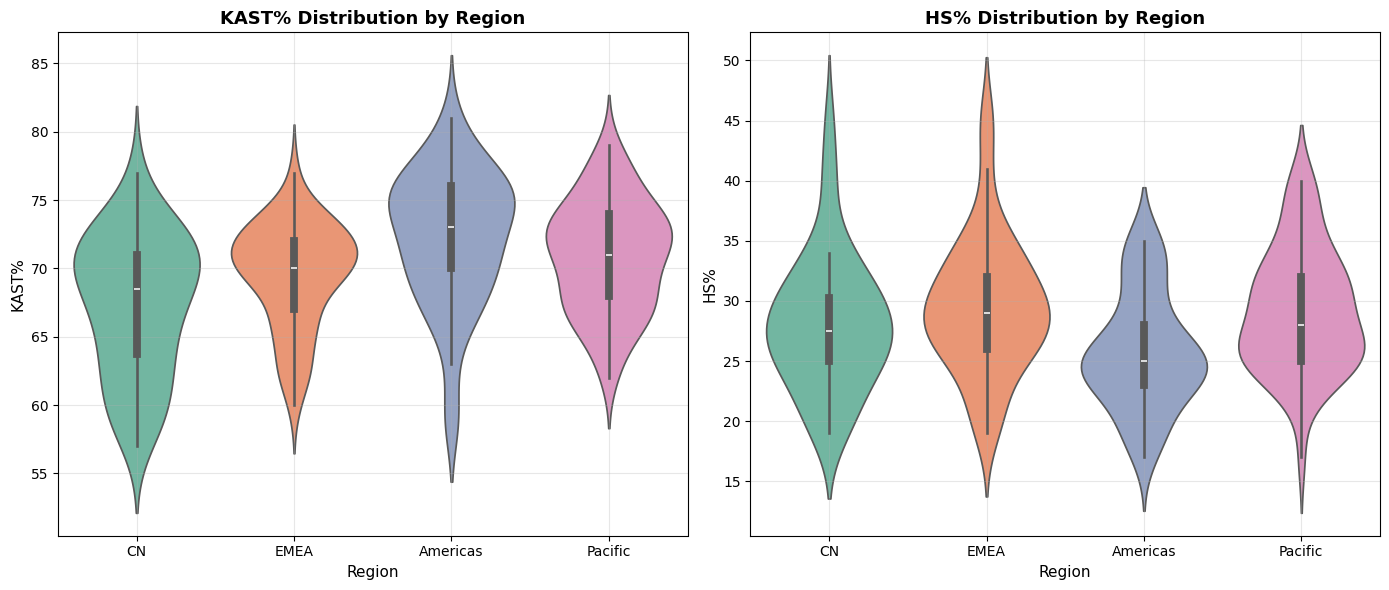

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=combined_df, x='Region', y='KAST', hue='Region',
               palette='Set2', ax=axes[0], inner='box', legend=False)
axes[0].set_title('KAST% Distribution by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region', fontsize=11)
axes[0].set_ylabel('KAST%', fontsize=11)
axes[0].grid(True, alpha=0.3)

sns.violinplot(data=combined_df, x='Region', y='HS%', hue='Region',
               palette='Set2', ax=axes[1], inner='box', legend=False)
axes[1].set_title('HS% Distribution by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region', fontsize=11)
axes[1].set_ylabel('HS%', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('violin_plots.png', dpi=150)
plt.show()

## 9. Normalised Regional Heatmap

The heatmap displays normalised performance scores for each region across all metrics. Values range from 0 (lowest performing region for that metric) to 1 (highest), allowing direct comparison across metrics with different scales.

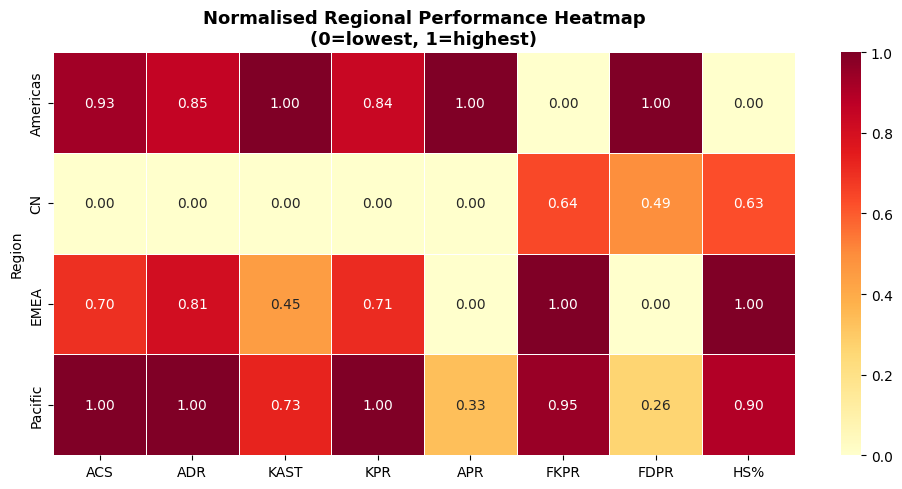

In [10]:
from sklearn.preprocessing import MinMaxScaler

fig, ax = plt.subplots(figsize=(10, 5))
heatmap_data = combined_df.groupby('Region')[['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%']].mean()
scaler = MinMaxScaler()
heatmap_normalised = pd.DataFrame(scaler.fit_transform(heatmap_data),
                                   index=heatmap_data.index,
                                   columns=heatmap_data.columns)
sns.heatmap(heatmap_normalised, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Normalised Regional Performance Heatmap\n(0=lowest, 1=highest)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regional_heatmap.png', dpi=150)
plt.show()

## 8. Statistical Analysis

The following statistical tests determine whether observed differences between regions are statistically significant.

- **Kruskal-Wallis Test**: Non-parametric test comparing all four regions simultaneously. A p-value below 0.05 indicates a significant difference exists somewhere between regions.
- **Mann-Whitney U Test**: Post-hoc pairwise test identifying which specific regional pairs drive the significant difference.

In [11]:
print("=" * 60)
print("STATISTICAL ANALYSIS OF REGIONAL DIFFERENCES")
print("=" * 60)

metrics_to_test = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']
regions = ['Americas', 'EMEA', 'Pacific', 'CN']

print("\nKruskal-Wallis Test Results:\n")
significant_metrics = []
for metric in metrics_to_test:
    groups = [combined_df[combined_df['Region'] == r][metric].dropna() for r in regions]
    stat, p = stats.kruskal(*groups)
    sig = '*** SIGNIFICANT' if p < 0.05 else 'not significant'
    if p < 0.05:
        significant_metrics.append(metric)
    print(f"{metric}: H={stat:.3f}, p={p:.4f} — {sig}")

print("\n" + "=" * 60)
print("Mann-Whitney U Post-Hoc Tests (significant metrics only):\n")
for metric in significant_metrics:
    print(f"--- {metric} ---")
    for r1, r2 in combinations(regions, 2):
        g1 = combined_df[combined_df['Region'] == r1][metric].dropna()
        g2 = combined_df[combined_df['Region'] == r2][metric].dropna()
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '*** SIGNIFICANT' if p < 0.05 else 'not significant'
        print(f"  {r1} vs {r2}: p={p:.4f} — {sig}")
    print()

STATISTICAL ANALYSIS OF REGIONAL DIFFERENCES

Kruskal-Wallis Test Results:

ACS: H=2.735, p=0.4342 — not significant
ADR: H=2.216, p=0.5288 — not significant
KAST: H=23.092, p=0.0000 — *** SIGNIFICANT
KPR: H=3.169, p=0.3664 — not significant
FKPR: H=0.420, p=0.9360 — not significant
HS%: H=15.314, p=0.0016 — *** SIGNIFICANT

Mann-Whitney U Post-Hoc Tests (significant metrics only):

--- KAST ---
  Americas vs EMEA: p=0.0017 — *** SIGNIFICANT
  Americas vs Pacific: p=0.0713 — not significant
  Americas vs CN: p=0.0000 — *** SIGNIFICANT
  EMEA vs Pacific: p=0.1179 — not significant
  EMEA vs CN: p=0.0432 — *** SIGNIFICANT
  Pacific vs CN: p=0.0014 — *** SIGNIFICANT

--- HS% ---
  Americas vs EMEA: p=0.0006 — *** SIGNIFICANT
  Americas vs Pacific: p=0.0009 — *** SIGNIFICANT
  Americas vs CN: p=0.0395 — *** SIGNIFICANT
  EMEA vs Pacific: p=0.6636 — not significant
  EMEA vs CN: p=0.1718 — not significant
  Pacific vs CN: p=0.3105 — not significant



## 11. Player Search

Search for any player by name to see all their stats across events.

In [13]:
search_widget = widgets.Text(placeholder='Type player name e.g. aspas', description='Player:', continuous_update=False)
search_out = widgets.Output()

def on_search(change):
    search_out.clear_output()
    with search_out:
        query = change['new'].strip().lower()
        if not query:
            return
        results = combined_df[combined_df['Player'].str.lower().str.contains(query)]
        if results.empty:
            print(f"No players found matching '{query}'")
            return
        print(f"Found {len(results)} result(s):\n")
        print(results[['Player', 'Team', 'Region', 'Event', 'ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']].to_string(index=False))
        
        if len(results) > 0:
            fig, ax = plt.subplots(figsize=(10, 4))
            metrics_plot = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'HS%']
            colors_map = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}
            for _, row in results.iterrows():
                values = [row[m] for m in metrics_plot]
                color = colors_map.get(row['Region'], 'grey')
                ax.bar([f"{m}\n({row['Event'][:7]})" for m in metrics_plot], values, alpha=0.7, color=color, edgecolor='black', label=f"{row['Player']} - {row['Event']}")
            ax.set_title(f"Stats for '{query}'", fontweight='bold', fontsize=13)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

search_widget.observe(on_search, names='value')
display(widgets.VBox([search_widget, search_out]))

## 12. Region vs Region Comparison

Pick two regions and compare their average performance head to head.


In [14]:
region1_widget = widgets.Dropdown(options=['Americas', 'EMEA', 'Pacific', 'CN'], value='Americas', description='Region 1')
region2_widget = widgets.Dropdown(options=['Americas', 'EMEA', 'Pacific', 'CN'], value='CN', description='Region 2')
compare_button = widgets.Button(description='Compare', button_style='primary')
compare_out = widgets.Output()

def on_compare(b):
    compare_out.clear_output()
    with compare_out:
        r1 = region1_widget.value
        r2 = region2_widget.value
        if r1 == r2:
            print("Please select two different regions.")
            return
        metrics_compare = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'FDPR', 'HS%']
        df1 = combined_df[combined_df['Region'] == r1][metrics_compare].mean()
        df2 = combined_df[combined_df['Region'] == r2][metrics_compare].mean()
        colors = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}
        fig, ax = plt.subplots(figsize=(12, 6))
        x = range(len(metrics_compare))
        width = 0.35
        bars1 = ax.bar([i - width/2 for i in x], df1.values, width, label=r1, color=colors[r1], edgecolor='black')
        bars2 = ax.bar([i + width/2 for i in x], df2.values, width, label=r2, color=colors[r2], edgecolor='black')
        ax.set_xticks(list(x))
        ax.set_xticklabels(metrics_compare, fontsize=11)
        ax.set_title(f'{r1} vs {r2} — Average Performance Comparison', fontweight='bold', fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.2f}', ha='center', fontsize=8)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.2f}', ha='center', fontsize=8)
        plt.tight_layout()
        plt.show()
        print(f"\n{'Metric':<10} {r1:<12} {r2:<12} {'Winner'}")
        print("-" * 45)
        for metric in metrics_compare:
            v1 = df1[metric]
            v2 = df2[metric]
            winner = r1 if v1 > v2 else r2
            print(f"{metric:<10} {v1:<12.2f} {v2:<12.2f} {winner}")

compare_button.on_click(on_compare)
display(widgets.VBox([region1_widget, region2_widget, compare_button, compare_out]))

## 13. Team Comparison

Pick two teams and compare their average stats side by side.

In [15]:
all_teams = sorted(combined_df['Team'].unique().tolist())
team1_widget = widgets.Dropdown(options=all_teams, value='MIBR', description='Team 1')
team2_widget = widgets.Dropdown(options=all_teams, value='T1', description='Team 2')
team_button = widgets.Button(description='Compare Teams', button_style='primary')
team_out = widgets.Output()

def on_team_compare(b):
    team_out.clear_output()
    with team_out:
        t1 = team1_widget.value
        t2 = team2_widget.value
        if t1 == t2:
            print("Please select two different teams.")
            return
        metrics_compare = ['ACS', 'ADR', 'KAST', 'KPR', 'FKPR', 'FDPR', 'HS%']
        df1 = combined_df[combined_df['Team'] == t1][metrics_compare].mean()
        df2 = combined_df[combined_df['Team'] == t2][metrics_compare].mean()
        colors_map = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}
        r1 = combined_df[combined_df['Team'] == t1]['Region'].iloc[0]
        r2 = combined_df[combined_df['Team'] == t2]['Region'].iloc[0]
        c1 = colors_map.get(r1, 'grey')
        c2 = colors_map.get(r2, 'grey')
        fig, ax = plt.subplots(figsize=(12, 6))
        x = range(len(metrics_compare))
        width = 0.35
        bars1 = ax.bar([i - width/2 for i in x], df1.values, width, label=f"{t1} ({r1})", color=c1, edgecolor='black')
        bars2 = ax.bar([i + width/2 for i in x], df2.values, width, label=f"{t2} ({r2})", color=c2, edgecolor='black')
        ax.set_xticks(list(x))
        ax.set_xticklabels(metrics_compare, fontsize=11)
        ax.set_title(f'{t1} vs {t2} — Average Performance Comparison', fontweight='bold', fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.2f}', ha='center', fontsize=8)
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.2f}', ha='center', fontsize=8)
        plt.tight_layout()
        plt.show()
        print(f"\n{'Metric':<10} {t1:<12} {t2:<12} {'Winner'}")
        print("-" * 45)
        for metric in metrics_compare:
            v1 = df1[metric]
            v2 = df2[metric]
            winner = t1 if v1 > v2 else t2
            print(f"{metric:<10} {v1:<12.2f} {v2:<12.2f} {winner}")

team_button.on_click(on_team_compare)
display(widgets.VBox([team1_widget, team2_widget, team_button, team_out]))

## 14. Performance Distribution

See how a metric is distributed across all players as a histogram, with regional breakdowns.

In [28]:
@interact(
    Metric=widgets.Dropdown(options=['ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDPR', 'HS%'], value='ACS'),
    Bins=widgets.IntSlider(min=10, max=40, step=5, value=20, description='Detail')
)
def performance_distribution(Metric, Bins):
    metric_names = {
        'ACS': 'Average Combat Score', 'ADR': 'Average Damage per Round',
        'KAST': 'Kill/Assist/Survive/Trade %', 'KPR': 'Kills per Round',
        'APR': 'Assists per Round', 'FKPR': 'First Kills per Round',
        'FDPR': 'First Deaths per Round', 'HS%': 'Headshot %'
    }
    full_name = metric_names.get(Metric, Metric)
    colors = {'Americas': '#2ecc71', 'EMEA': '#e74c3c', 'Pacific': '#3498db', 'CN': '#f39c12'}

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Distribution of {full_name} ({Metric})', fontsize=15, fontweight='bold', y=1.02)

    data = combined_df[Metric].dropna()
    mean_val = data.mean()
    median_val = data.median()
    axes[0].hist(data, bins=Bins, color='#3498db', edgecolor='white', alpha=0.85, linewidth=0.5)
    axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Average: {mean_val:.1f}')
    axes[0].axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[0].set_title('All Players Combined', fontweight='bold', fontsize=13, pad=10)
    axes[0].set_xlabel(f'{Metric} — {full_name}', fontsize=11)
    axes[0].set_ylabel('Number of Players', fontsize=11)
    axes[0].legend(fontsize=10, framealpha=0.9)
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    for region, group in combined_df.groupby('Region'):
        axes[1].hist(group[Metric].dropna(), bins=Bins, alpha=0.55,
                    label=f"{region} (avg: {group[Metric].mean():.1f})",
                    color=colors.get(region, 'grey'), edgecolor='white', linewidth=0.5)
    axes[1].set_title('Broken Down by Region', fontweight='bold', fontsize=13, pad=10)
    axes[1].set_xlabel(f'{Metric} — {full_name}', fontsize=11)
    axes[1].set_ylabel('Number of Players', fontsize=11)
    axes[1].legend(title='Region (with average)', fontsize=10, framealpha=0.9)
    axes[1].grid(True, alpha=0.3, linestyle='--')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    from IPython.display import display, HTML

# Metric label + colour legend
    legend_html = f"""
    <div style="margin: 20px 0 10px 0; font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 12px 16px; border-radius: 8px; border-left: 4px solid #2c3e50;">
        <div style="font-size: 15px; font-weight: bold; color: #2c3e50; margin-bottom: 10px;">
            📊 Showing: {full_name} ({Metric})
        </div>
        <div style="font-size: 12px; color: #555; margin-bottom: 6px;">
            <strong>Each row represents one VCT region.</strong> Columns show how that region's players performed on average across all three 2025 tournaments.
        </div>
        <div style="margin-top: 8px;">
            <span style="font-size: 12px; color: #555; font-weight: bold;">Row colour = Region:&nbsp;&nbsp;</span>
            <span style="background-color: #d5f5e3; color: #1a5e35; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ Americas</span>
            <span style="margin-left: 6px; background-color: #fadbd8; color: #7b241c; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ EMEA</span>
            <span style="margin-left: 6px; background-color: #d6eaf8; color: #1a5276; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ Pacific</span>
            <span style="margin-left: 6px; background-color: #fdebd0; color: #784212; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ CN</span>
            <span style="margin-left: 6px; background-color: #eaecee; color: #424949; padding: 3px 10px; border-radius: 4px; font-size: 12px; font-weight: bold;">■ Overall</span>
        </div>
        <div style="margin-top: 8px; font-size: 12px; color: #555;">
            <span style="color: #1e8449; font-weight: bold;">● Green text</span> = highest value in that column &nbsp;&nbsp;
            <span style="color: #c0392b; font-weight: bold;">● Red text</span> = lowest value in that column
        </div>
    </div>
    """
    display(HTML(legend_html))
    display(HTML(legend_html))
    display(HTML(legend_html))

    # Build summary data
    summary_data = []
    for region, group in combined_df.groupby('Region'):
        d = group[Metric].dropna()
        summary_data.append({
            'Region': region,
            'Average': round(d.mean(), 2),
            'Median': round(d.median(), 2),
            'Lowest': round(d.min(), 2),
            'Highest': round(d.max(), 2),
            'Std Dev': round(d.std(), 2),
            'Players': int(len(d))
        })

    overall = combined_df[Metric].dropna()
    summary_data.append({
        'Region': 'Overall',
        'Average': round(overall.mean(), 2),
        'Median': round(overall.median(), 2),
        'Lowest': round(overall.min(), 2),
        'Highest': round(overall.max(), 2),
        'Std Dev': round(overall.std(), 2),
        'Players': int(len(overall))
    })

    summary_df = pd.DataFrame(summary_data).set_index('Region')

    region_colors = {
        'Americas': '#d5f5e3',
        'CN': '#fdebd0',
        'EMEA': '#fadbd8',
        'Pacific': '#d6eaf8',
        'Overall': '#eaecee'
    }

    numeric_cols = ['Average', 'Median', 'Lowest', 'Highest', 'Std Dev']
    max_vals = summary_df[numeric_cols].iloc[:-1].max()
    min_vals = summary_df[numeric_cols].iloc[:-1].min()

    def style_cells(val, col):
        if col not in numeric_cols:
            return 'color: black'
        if val == max_vals[col]:
            return 'color: green; font-weight: bold'
        if val == min_vals[col]:
            return 'color: red; font-weight: bold'
        return 'color: black'

    def highlight_rows(row):
        color = region_colors.get(row.name, 'white')
        weight = 'bold' if row.name == 'Overall' else 'normal'
        return [f'background-color: {color}; font-weight: {weight}'] * len(row)

    styled = summary_df.style.apply(highlight_rows, axis=1)

    for col in numeric_cols:
        styled = styled.map(lambda val, c=col: style_cells(val, c), subset=[col])

    styled = styled.set_caption(f'{full_name} ({Metric}) — Regional Summary') \
        .set_table_styles([
            {'selector': 'caption', 'props': [
                ('font-size', '14px'), ('font-weight', 'bold'),
                ('padding', '10px'), ('color', 'black')]},
            {'selector': 'th', 'props': [
                ('background-color', '#2c3e50'), ('color', 'white'),
                ('font-size', '12px'), ('padding', '8px 14px'),
                ('text-align', 'center'), ('border', '1px solid #ccc')]},
            {'selector': 'td', 'props': [
                ('padding', '8px 14px'), ('text-align', 'center'),
                ('font-size', '12px'), ('border', '1px solid #ddd')]},
            {'selector': 'tr:hover td', 'props': [('opacity', '0.85')]}
        ])

    display(styled)

interactive(children=(Dropdown(description='Metric', options=('ACS', 'ADR', 'KAST', 'KPR', 'APR', 'FKPR', 'FDP…